# HOG Feature Extraction

This notebook extracts HOG features from the iNaturalist images.

## Import Libraries and Settings

Load the needed libraries and shared project configuration.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from skimage.color import rgb2gray
from skimage.feature import hog

# Find the project root
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src").exists() and (path / "data").exists()
)

# Allow imports from the project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config

print("Project root:", PROJECT_ROOT)
print("Image size:", config.IMG_SIZE)

Project root: c:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group
Image size: (224, 224)


## Load a Sample Image

Read one training image and resize it to the shared input size.

Image path: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\data\raw\train_mini\07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii\f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg
Label: 364
Species: Xylorhiza orcuttii
Image size: (224, 224)


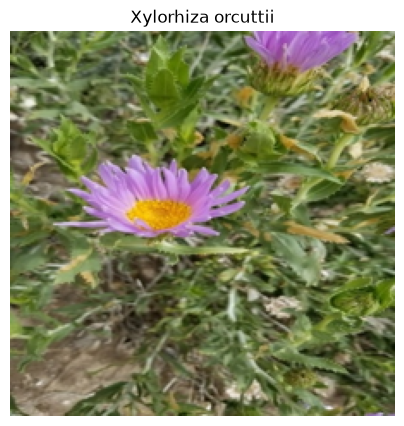

In [18]:
# Read the training manifest
train_df = pd.read_csv(config.TRAIN_CSV)

# Use the first image for testing
sample = train_df.iloc[0]
image_path = config.DATA_RAW_ROOT / sample["file_path"]

# Load and resize the image
image = Image.open(image_path).convert("RGB")
image = image.resize(config.IMG_SIZE)

print("Image path:", image_path)
print("Label:", sample["label"])
print("Species:", sample["category_name"])
print("Image size:", image.size)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(sample["category_name"])
plt.axis("off")
plt.show()

## Extract the HOG Feature

Convert the image to grayscale and extract its HOG feature vector.

In [9]:
# Convert the image to grayscale
gray_image = rgb2gray(image)

# Extract the HOG feature and visualisation
hog_feature, hog_image = hog(
    gray_image,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True
)

print("HOG feature shape:", hog_feature.shape)
print("HOG feature length:", len(hog_feature))

HOG feature shape: (6084,)
HOG feature length: 6084


## Visualise the HOG 

Compare the original image with its HOG visualisation.

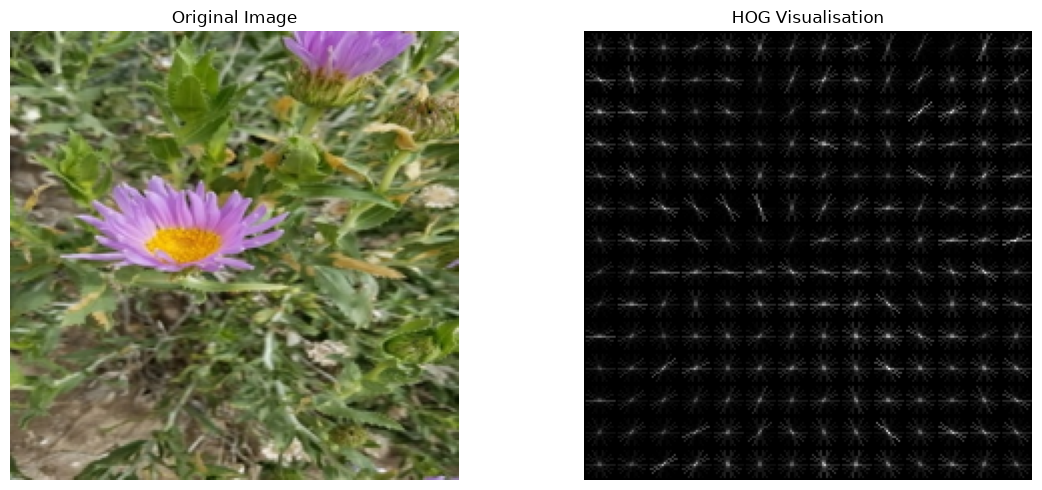

In [10]:
# Show the original image and HOG visualisation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Visualisation")
plt.axis("off")

plt.tight_layout()
plt.show()

## Create a Reusable HOG Function

Define a function that extracts the same HOG feature from any PIL image.

In [11]:
import numpy as np


def extract_hog_feature(image):
    """Extract a fixed-length HOG feature from a PIL image."""

    # Resize and convert the image to grayscale
    resized_image = image.convert("RGB").resize(config.IMG_SIZE)
    gray_image = rgb2gray(resized_image)

    # Extract the HOG feature
    feature = hog(
        gray_image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )

    return feature.astype(np.float32)

## Test the HOG Function

Check the feature type, data type, and output length.

In [12]:
# Test the reusable HOG function
test_feature = extract_hog_feature(image)

print("Feature type:", type(test_feature))
print("Feature data type:", test_feature.dtype)
print("Feature shape:", test_feature.shape)
print("Feature length:", len(test_feature))

Feature type: <class 'numpy.ndarray'>
Feature data type: float32
Feature shape: (6084,)
Feature length: 6084


## Test Images from Different Classes

Check that images from different species produce features with the same length.

In [16]:
# Select images from different classes
sample_rows = (
    train_df
    .drop_duplicates(subset="label")
    .head(5)
)

feature_lengths = []

for index, sample in sample_rows.iterrows():
    sample_path = config.DATA_RAW_ROOT / sample["file_path"]

    with Image.open(sample_path) as sample_image:
        sample_feature = extract_hog_feature(sample_image)

    feature_lengths.append(len(sample_feature))

    print(
        "Label:",
        sample["label"],
        "- Species:",
        sample["category_name"],
        "- Feature length:",
        len(sample_feature)
    )

print("All feature lengths:", feature_lengths)
print("Same length:", len(set(feature_lengths)) == 1)

Label: 364 - Species: Xylorhiza orcuttii - Feature length: 6084
Label: 251 - Species: Sceloporus orcutti - Feature length: 6084
Label: 449 - Species: Malvaviscus arboreus - Feature length: 6084
Label: 404 - Species: Lysimachia clethroides - Feature length: 6084
Label: 199 - Species: Pycnonotus leucotis - Feature length: 6084
All feature lengths: [6084, 6084, 6084, 6084, 6084]
Same length: True


## Summary

Each image is resized to 224 × 224 and converted to grayscale before HOG extraction.

The descriptor produces a fixed-length feature vector of 6084 values, which can later be combined with the colour feature and used by the SVM classifier.